In [ ]:
pip install pillow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---- Exercise 1 ----


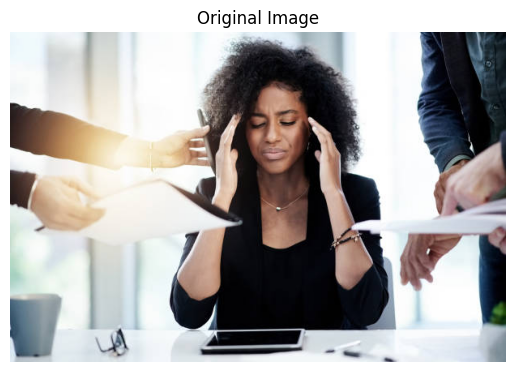

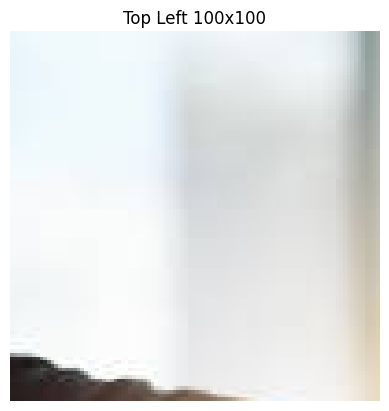

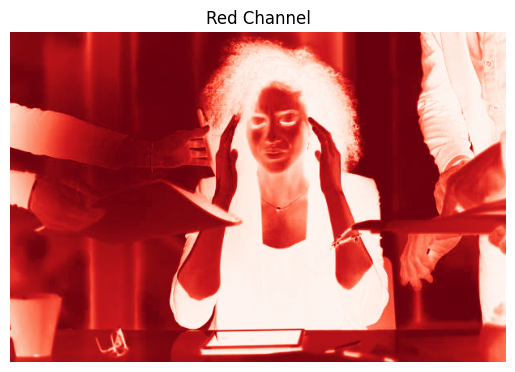

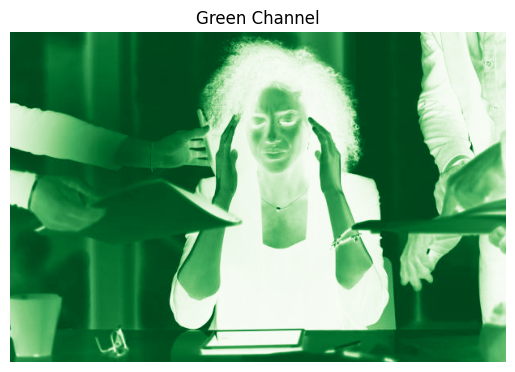

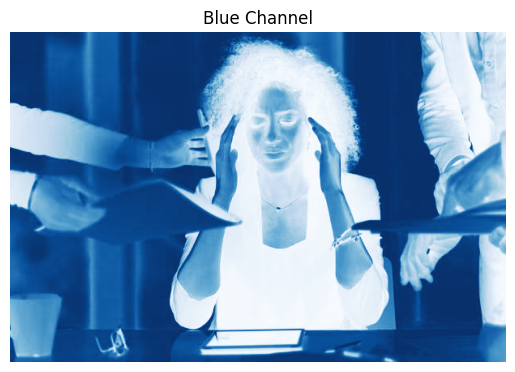

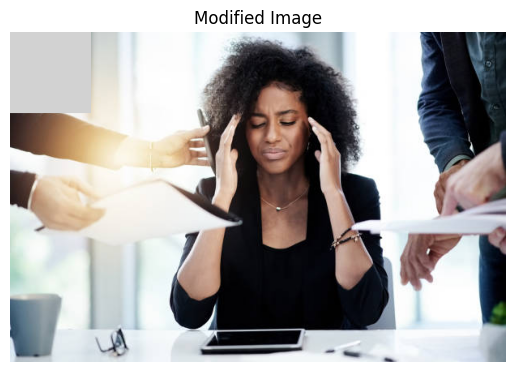

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

print("---- Exercise 1 ----")

# 1. Read and display image
img = Image.open('/content/drive/MyDrive/AI_Machine_Learning/Week2/image.jpg')
img_array = np.array(img)

plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

# 2. Top-left 100x100
top_left = img_array[:100, :100]

plt.imshow(top_left)
plt.title("Top Left 100x100")
plt.axis("off")
plt.show()

# 3. Separate RGB channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis("off")
plt.show()

plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")
plt.show()

plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")
plt.show()

# 4. Modify top-left 100x100 to 210
modified = img_array.copy()
modified[:100, :100] = 210

plt.imshow(modified)
plt.title("Modified Image")
plt.axis("off")
plt.show()

---- Exercise 2 ----


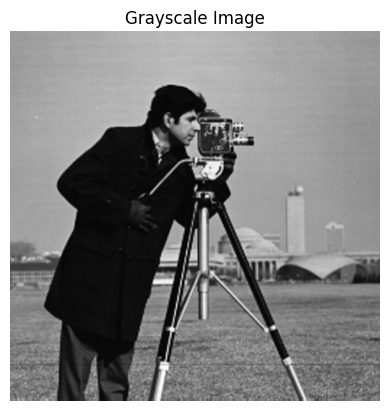

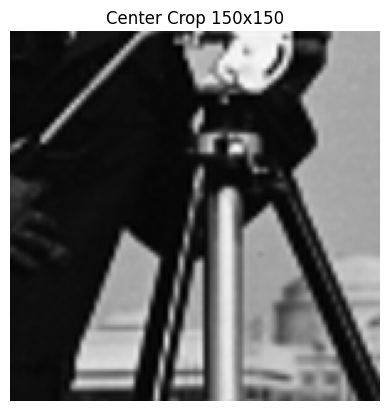

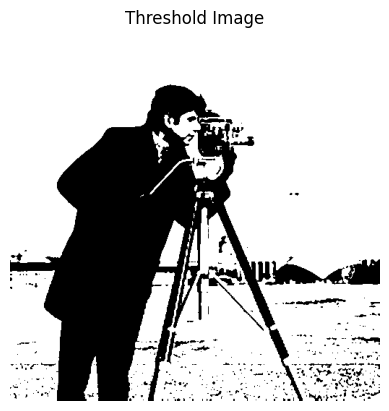

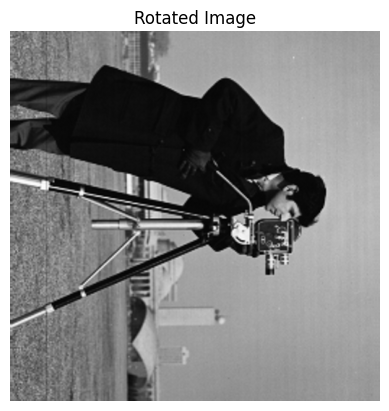

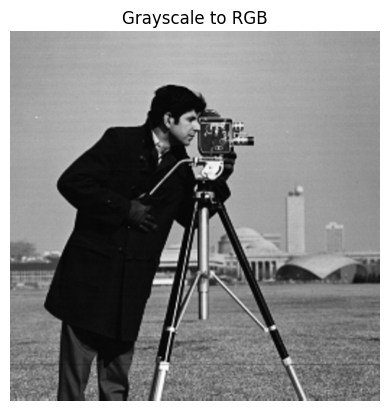

In [ ]:
print("---- Exercise 2 ----")

# 1. Load grayscale image
gray_img = Image.open("/content/drive/MyDrive/AI_Machine_Learning/Week2/cameraman.png").convert("L")
gray_array = np.array(gray_img)

plt.imshow(gray_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

# 2. Middle 150x150 crop
h, w = gray_array.shape
center = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center, cmap='gray')
plt.title("Center Crop 150x150")
plt.axis("off")
plt.show()

# 3. Threshold
binary = gray_array.copy()
binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap='gray')
plt.title("Threshold Image")
plt.axis("off")
plt.show()

# 4. Rotate 90 degree clockwise
rotated = np.rot90(gray_array, k=-1)

plt.imshow(rotated, cmap='gray')
plt.title("Rotated Image")
plt.axis("off")
plt.show()

# 5. Convert grayscale to RGB
rgb = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb)
plt.title("Grayscale to RGB")
plt.axis("off")
plt.show()

---- PCA Image Compression ----


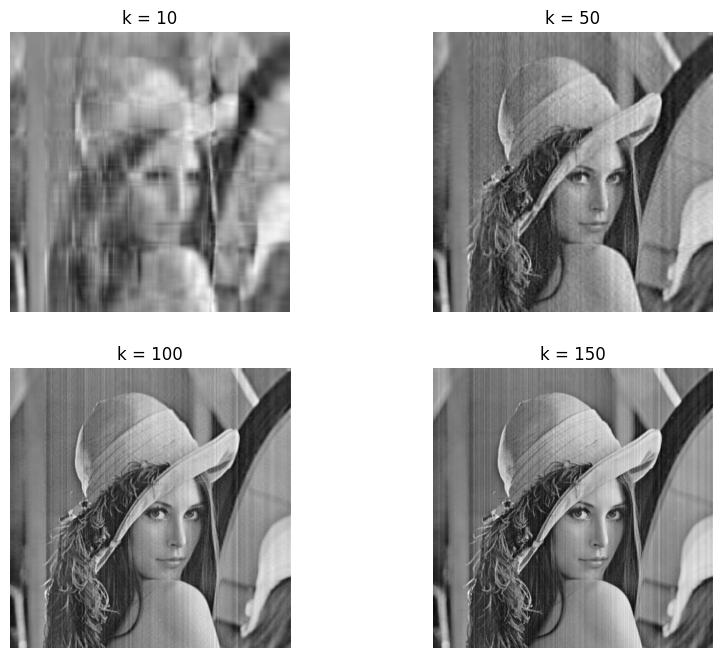

In [ ]:
print("---- PCA Image Compression ----")

# 1. Load image and convert to grayscale
img = Image.open("/content/drive/MyDrive/AI_Machine_Learning/Week2/lena_gray.gif").convert("L")
img_array = np.array(img, dtype=float)

# Normalize (standardize)
mean = np.mean(img_array)
std = np.std(img_array)
X = (img_array - mean) / std

# 2. Covariance matrix
cov_matrix = np.cov(X, rowvar=False)

# 3. Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 4. Select k components
k_values = [10, 50, 100, 150]

plt.figure(figsize=(10,8))

for i, k in enumerate(k_values):
    V_k = eigenvectors[:, :k]

    # Project
    X_reduced = np.dot(X, V_k)

    # Reconstruct
    X_reconstructed = np.dot(X_reduced, V_k.T)

    # De-normalize
    X_reconstructed = np.real(X_reconstructed)
    X_reconstructed = X_reconstructed * std + mean

    plt.subplot(2,2,i+1)
    plt.imshow(X_reconstructed, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis("off")

plt.show()